# Assignment \#3: Bronsted Plot

This notebook explores the data used for assignment #3 and plots the data in a Bronsted Plot. The plots are used in the exploration docume nt for this assignment.

## Setup Tools

Here the libraries are imported and any functions defined

In [38]:
# Install packages only if needed
# Coogle Colab does not include every Python package
#   
try:                  # if the package exists import it, otherwise install it
    import lmfit
except ImportError:
    !pip -q install lmfit
    import lmfit

try:
    import uncertainties
except ImportError:
    !pip -q install uncertainties
    import uncertainties

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un
from uncertainties import unumpy as unp

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import t

from pathlib import Path

Path("plots").mkdir(exist_ok=True)
#Path("data").mkdir(exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#if IN_COLAB and not Path("data/3c.csv").exists():
#    !wget -q -O data/3c.csv https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/notebooks/M11_Plot_Recommendations/3c.csv

if IN_COLAB and not Path("tufte.mplstyle").exists():
    !wget -q https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/styles/tufte.mplstyle
if IN_COLAB and not Path("data").exists():
    !wget -q https://raw.github.com/blinkletter/Chem4410Webbook/main/book/notebooks/A03_Bronsted_Plot/data.zip
    !unzip -q data.zip

plt.rcdefaults()

print("Setup complete")


Setup complete


## Basic Plot

Below is code to read in the data and plot the Brønsted plot.

[[Model]]
    Model(bronsted)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 63
    # variables        = 2
    chi-square         = 28.8075463
    reduced chi-square = 0.47225486
    Akaike info crit   = -45.2973331
    Bayesian info crit = -41.0110636
    R-squared          = 0.83375022
[[Variables]]
    alpha:  0.51108537 +/- 0.02922073 (5.72%) (init = 0.5)
    logk0:  3.59101153 +/- 0.19023204 (5.30%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(alpha, logk0) = +0.8904


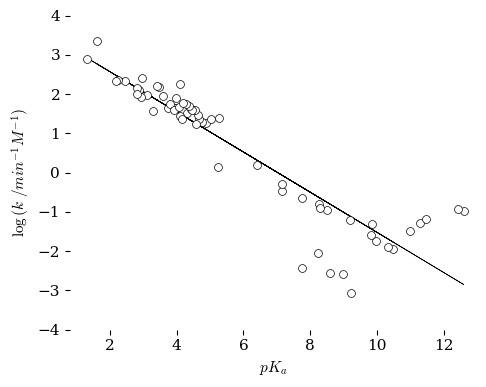

In [64]:
### READ DATA

data_file = "data/Data2All_labeled.csv"   

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

x = -np.log10(df["Ka"])
y = np.log10(df["k"])

def bronsted(pKa, alpha, logk0):
    """
    Bronsted equation: log(k) = -alpha * pKa + logk0
    """
    return -alpha * pKa + logk0

mod = lmfit.Model(bronsted) 

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(alpha = dict(value = 0.5), 
                       logk0 =  dict(value = 1),
                      )

# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pKa=x)   
print(result.fit_report())


y_fit = y1 = result.eval(pKa = x)


######################
### Plots - NEW STYLED PLOTTING SECTION
######################

plt.rcdefaults()

style = "tufte.mplstyle"
#style = "S2_classic2.mplstyle"
style_name = style
plt.style.use(style_name)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,4])

# Settings for plot
ax.set(
#          title = Title,       
          ylabel=r"$\log{(k\ /min^{-1}M^{-1})}$",                
          xlabel=r"$pK_a$ ", 
#          xlim=[np.min(x)-0.2, np.max(x)+0.2],                  
          xlim=[0.8, 13],                  
          ylim=[-4,4]
#          xticks = [1,3,5,7],
#          yticks = [0,-1,-2,-3],
       )

### Data graphics
ax.scatter(x, y, marker = "o", s = 32, 
              color = "white", edgecolors = "black", 
              linewidths=0.5, zorder = 4) 
if 1:
    ax.plot(x,y_fit, 
           marker = None, color = "black", 
           linewidth=0.5, zorder = 3)

if 0:
    ax.fill_between(
        x_fit, ci_lower, ci_upper,
        linewidth = 0,
        facecolor="gray", 
        edgecolor = "gray", 
        alpha=0.20,
        label="95% Confidence Band",
        zorder = 2,
        )



################################################
### Output Plot
################################################

name = "plot2"

# Plot as .pdf
plt.savefig(f"plots/{name}.pdf")

### Set face of plot to transparent
ax.patch.set_facecolor([0, 0, 0, 0])  

# Plot as .png with transparent background
plt.savefig(f"plots/{name}.png", dpi=600, 
            facecolor = [0, 0, 0, 0],
        )
# display plot in notebook
plt.show()


## Compute Statistical Confidence Intervals

Below is code to extract the confidence interval from the curve fit result. I will be pasting this code into any plots that use confidence and/or prediction intervals.

In [40]:
# line fit
x_fit = np.linspace(np.min(x)-0.1, np.max(x)+0.1, 50)     # make an array of 50 points that span the data range
y_fit = result.eval(pKa=x_fit)                      # the line of the line fit

# confidence interval
y_err = result.eval_uncertainty(pKa=x_fit, sigma=2) # the 95% confidence interval
ci_upper = y_fit + y_err
ci_lower = y_fit - y_err

# Prediction interval

se = result.eval_uncertainty(pKa=x_fit, sigma=1)  # standard error of the fit
mse = result.redchi                             # reduced chi-squared value from the fit (mean squared error)
se_pred = np.sqrt(se**2 + mse)

dof = result.ndata - result.nvarys # degrees of freedom = number of data points - number of fitted parameters
tval = t.ppf(0.975,dof)            # two-tailed t-value for 95% confidence interval
pi = tval * se_pred

pi_lower = y_fit - pi
pi_upper = y_fit + pi

## Plot with data Excluded

Below is the plot using only the data for carbozylic acids and phenols in the curve fit. I have set up options to also visualize unused data.

[[Model]]
    Model(bronsted)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 47
    # variables        = 2
    chi-square         = 2.23250241
    reduced chi-square = 0.04961116
    Akaike info crit   = -139.210151
    Bayesian info crit = -135.509856
    R-squared          = 0.97451527
[[Variables]]
    alpha:  0.52988739 +/- 0.01277389 (2.41%) (init = 0.5)
    logk0:  3.64437976 +/- 0.06983314 (1.92%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(alpha, logk0) = +0.8852


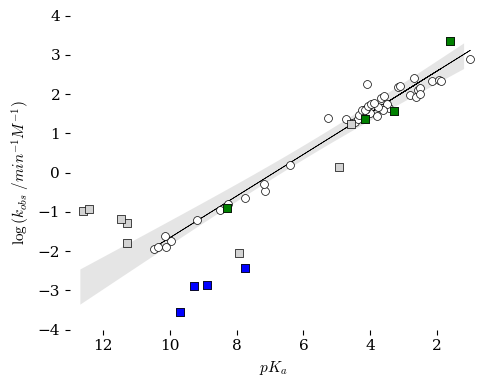

In [41]:
### READ DATA

data_file = "data/Data2All_labeled.csv"   

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

df["log_k"] = np.log10(df["k"]/df["p"])
df["pKa"] = -np.log10(df["Ka"]*df["q"]/df["p"])


selected_df = df[
        df["label"].isin(["carb. acid", "mp-benz. acid", "o-benz. acid", "phenol"])
]

x = selected_df["pKa"]
y = selected_df["log_k"]

def bronsted(pKa, alpha, logk0):
    """
    Bronsted equation: log(k) = -alpha * pKa + logk0
    """
    return -alpha * pKa + logk0

mod = lmfit.Model(bronsted) 

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(alpha = dict(value = 0.5), 
                       logk0 =  dict(value = 1),
                      )

# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pKa=x)   
print(result.fit_report())

y_fit = y1 = result.eval(pKa = x)


######################
### Plots - NEW STYLED PLOTTING SECTION
######################

plt.rcdefaults()

style = "tufte.mplstyle"
#style = "S2_classic2.mplstyle"
style_name = style
plt.style.use(style_name)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,4])

# Settings for plot
ax.set(
#          title = Title,       
          ylabel=r"$\log{(k_{obs}\ /min^{-1}M^{-1})}$",                
          xlabel=r"$pK_a$ ", 
          xlim=[13, 0.8],                  
          ylim=[-4,4]
#          xticks = [1,3,5,7],
#          yticks = [0,-1,-2,-3],
       )

### Data graphics
ax.scatter(x, y, marker = "o", s = 32, 
              color = "white", edgecolors = "black", 
              linewidths=0.5, zorder = 4) 
if 1:
    ax.plot(x,y_fit, 
           marker = None, color = "black", 
           linewidth=0.5, zorder = 3)

if 1:
    ax.fill_between(
        x_fit, ci_lower, ci_upper,
        linewidth = 0,
        facecolor="gray", 
        edgecolor = "gray", 
        alpha=0.20,
        label="95% Confidence Band",
        zorder = 0,
        )

################################################

if 1:
    selected_df = df[
        ~df["label"].isin(["carb. acid", "mp-benz. acid", "o-benz. acid", "phenol"])
        ]

    x = selected_df["pKa"]
    y = selected_df["log_k"]

    ax.scatter(x, y, marker = "s", s = 32, 
                  color = "lightgray", edgecolors = "black", 
                  linewidths=0.5, zorder = 4) 

if 1:
    selected_df = df[
        df["label"].isin(["alkane"])
    ]

    x = selected_df["pKa"]
    y = selected_df["log_k"]

    ax.scatter(x, y, marker = "s", s = 32, 
                  color = "blue", edgecolors = "black", 
                  linewidths=0.5, zorder = 4) 

if 1:
    selected_df = df[
        df["label"].isin(["other"])
    ]

    x = selected_df["pKa"]
    y = selected_df["log_k"]

    ax.scatter(x, y, marker = "s", s = 32, 
                  color = "green", edgecolors = "black", 
                  linewidths=0.5, zorder = 4) 

################################################
### Output Plot
################################################

name = "plot3"

# Plot as .pdf
plt.savefig(f"plots/{name}.pdf")

### Set face of plot to transparent
ax.patch.set_facecolor([0, 0, 0, 0])  

# Plot as .png with transparent background
plt.savefig(f"plots/{name}.png", dpi=600, 
            facecolor = [0, 0, 0, 0],
        )
# display plot in notebook
plt.show()


## Interactive Plot

the plot below uses the *Plotly* package rather than *MatPlotLib*. It produces a plot quickly and easily that can be querried by mouse-over. The points are coloured according to the calssification in the "label" column of the data. Each point is identfied according to the name of the acid in the "ACID" column of the data.

You can export the interactive plot as HTML code for inclusion in a website. Just ask ChatGPT how.

In [42]:
import plotly.express as px

data_file = "data/Data2All_labeled.csv"   

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

df["log_k"] = np.log10(df["k"]/df["p"])                # Calculate log of observed rate constant (with statistical correction)
df["pKa"] = -np.log10(df["q"]*df["Ka"]/df["p"]) # Calculate pKa (with statistical correction)

fig = px.scatter(           # create a scatter plot using Plotly Express
        df,          # use the modified dataframe from above
        x="pKa",            # set the x-axis to the calculated pKa values
        y="log_k",          # set the y-axis to the calculated log of observed rate constants
        hover_name="ACID",  # display the "ACID" column when hovering over points
        color="label",      # color points based on the "label" column
        height=700,         # set the height of the plot
        width=800,          # set the width of the plot
    )

fig.update_layout(showlegend=False)     # hide legend
fig.update_xaxes(autorange="reversed")  # reverse x-axis to match the published plot

fig.show()

display(df.head(3))


,NUMBER,ACID,k,Ka,p,q,label,log_k,pKa
0,1,propionic,18.0,0.000013,1,2,carb. acid,1.255273,4.568636
1,2,acetic,19.2,0.000018,1,2,carb. acid,1.283301,4.453457
2,3,beta-phenylpropionic,23.0,0.000022,1,2,carb. acid,1.361728,4.358526


## Copy of the Published Plot

the code below is the same as above but setn up to make a plot as similar to the publication as possible.

[[Model]]
    Model(bronsted)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 47
    # variables        = 2
    chi-square         = 2.23250241
    reduced chi-square = 0.04961116
    Akaike info crit   = -139.210151
    Bayesian info crit = -135.509856
    R-squared          = 0.97451527
[[Variables]]
    alpha:  0.52988739 +/- 0.01277389 (2.41%) (init = 0.5)
    logk0:  3.64437976 +/- 0.06983314 (1.92%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(alpha, logk0) = +0.8852


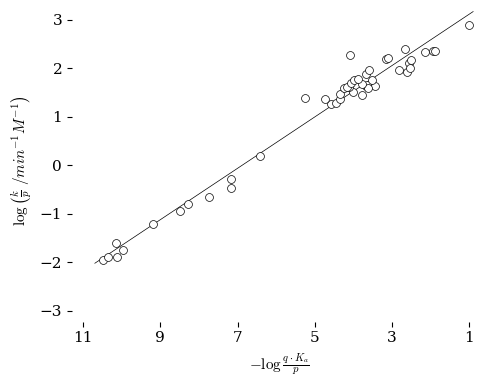

In [63]:
### READ DATA

data_file = "data/Data2All_labeled.csv"   

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

df["k"] = df["k"]/df["p"]
df["Ka"] = df["Ka"]*df["q"]/df["p"]

selected_df = df[
        df["label"].isin(["carb. acid", "mp-benz. acid", "o-benz. acid", "phenol"])
]

x = -np.log10(selected_df["Ka"])
#y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
y = np.log10(selected_df["k"])

def bronsted(pKa, alpha, logk0):
    """
    Bronsted equation: log(k) = -alpha * pKa + logk0
    """
    return -alpha * pKa + logk0

mod = lmfit.Model(bronsted) 

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(alpha = dict(value = 0.5), 
                       logk0 =  dict(value = 1),
                      )

# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pKa=x)   
print(result.fit_report())

x_fit = np.linspace(np.min(x)-0.1, np.max(x)+0.2, 50)     # make an array of 50 points that span the data range
y_fit = y1 = result.eval(pKa = x_fit)


######################
### Plots - NEW STYLED PLOTTING SECTION
######################

plt.rcdefaults()

style = "tufte.mplstyle"
#style = "S2_classic2.mplstyle"
style_name = style
plt.style.use(style_name)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,4])
ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))

# Settings for plot
ax.set(
#          title = Title,       
          ylabel=r"$\log{\left(\frac{k}{p}\ /min^{-1}M^{-1}\right)}$",                
          xlabel=r"$-\log{\frac{q\cdot K_a}{p}}$ ", 
          xlim=[11, 0.8],                  
          ylim=[-3,3.2],
#          yticks = [1,3,5,7],
          xticks = [11,9,7,5,3,1],
       )

### Data graphics
ax.scatter(x, y, marker = "o", s = 32, 
              color = "white", edgecolors = "black", 
              linewidths=0.5, zorder = 4) 
if 1:
    ax.plot(x_fit,y_fit, 
           marker = None, color = "black", 
           linewidth=0.5, zorder = 3)

if 0:
    ax.fill_between(
        x_fit, ci_lower, ci_upper,
        linewidth = 0,
        facecolor="gray", 
        edgecolor = "gray", 
        alpha=0.20,
        label="95% Confidence Band",
        zorder = 0,
        )

################################################

if 0:
    selected_df = df[
        df["label"].isin(["mp-benz. acid"])
        ]

    x = -np.log10(selected_df["Ka"])
    #y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = 32, 
                  color = "green", edgecolors = "black", 
                  linewidths=0.5, zorder = 4) 

if 0:
    selected_df = df[
        df["label"].isin(["o-benz. acid"])
    ]

    x = -np.log10(selected_df["Ka"])
    #y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = 32, 
                  color = "blue", edgecolors = "black", 
                  linewidths=0.5, zorder = 4) 


################################################
### Output Plot
################################################

name = "plot4"

# Plot as .pdf
plt.savefig(f"plots/{name}.pdf")

### Set face of plot to transparent
ax.patch.set_facecolor([0, 0, 0, 0])  

# Plot as .png with transparent background
plt.savefig(f"plots/{name}.png", dpi=600, 
            facecolor = [0, 0, 0, 0],
        )
# display plot in notebook
plt.show()


## Same Again, Different Style

The same plot as above. This time I am stacking data points to create an effect that highlights data grouping. I also added color ro the set of m,p-substituted benzoic acids and the ortho-substituted benzoic acids. The authors dedicate about a page to the observations that the m,p-substituted benzoic acids trend above the line (red highlight) while the ortho series trends below (blue highlight). This plot shows that in an artistic way.

[[Model]]
    Model(bronsted)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 47
    # variables        = 2
    chi-square         = 2.23250241
    reduced chi-square = 0.04961116
    Akaike info crit   = -139.210151
    Bayesian info crit = -135.509856
    R-squared          = 0.97451527
[[Variables]]
    alpha:  0.52988739 +/- 0.01277389 (2.41%) (init = 0.5)
    logk0:  3.64437976 +/- 0.06983314 (1.92%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(alpha, logk0) = +0.8852


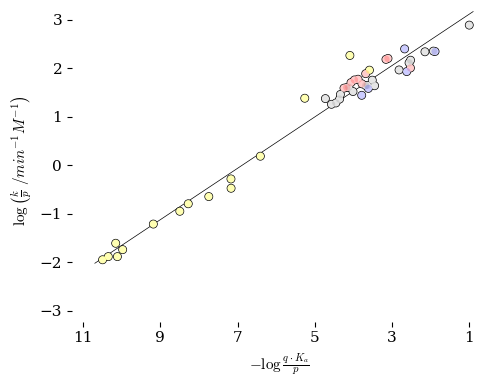

In [62]:
### READ DATA

data_file = "data/Data2All_labeled.csv"   

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

df["k"] = df["k"]/df["p"]
df["Ka"] = df["Ka"]*df["q"]/df["p"]

selected_df = df[
        df["label"].isin(["carb. acid", "mp-benz. acid", "o-benz. acid", "phenol"])
]

x = -np.log10(selected_df["Ka"])
#y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
y = np.log10(selected_df["k"])

def bronsted(pKa, alpha, logk0):
    """
    Bronsted equation: log(k) = -alpha * pKa + logk0
    """
    return -alpha * pKa + logk0

mod = lmfit.Model(bronsted) 

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(alpha = dict(value = 0.5), 
                       logk0 =  dict(value = 1),
                      )

# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pKa=x)   
print(result.fit_report())

x_fit = np.linspace(np.min(x)-0.1, np.max(x)+0.2, 50)     # make an array of 50 points that span the data range
y_fit = y1 = result.eval(pKa = x_fit)


######################
### Plots - NEW STYLED PLOTTING SECTION
######################

plt.rcdefaults()

style = "tufte.mplstyle"
#style = "S2_classic2.mplstyle"
style_name = style
plt.style.use(style_name)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,4])
ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))

# Settings for plot
ax.set(
#          title = Title,       
          ylabel=r"$\log{\left(\frac{k}{p}\ /min^{-1}M^{-1}\right)}$",                
          xlabel=r"$-\log{\frac{q\cdot K_a}{p}}$ ", 
          xlim=[11, 0.8],                  
          ylim=[-3,3.2],
#          yticks = [1,3,5,7],
          xticks = [11,9,7,5,3,1],
       )

### Data graphics
ax.scatter(x, y, marker = "o", s = 40, 
              color = "black", edgecolors = "none", 
              linewidths=0, zorder = 4) 
ax.scatter(x, y, marker = "o", s = 28, 
              color = "white", edgecolors = "none", 
              linewidths=0, zorder = 5) 
#ax.scatter(x, y, marker = "o", s = 28, 
#              color = "black", alpha = 0.1, edgecolors = "none", 
#              linewidths=0, zorder = 8) 

if 1:
    ax.plot(x_fit,y_fit, 
           marker = None, color = "black", 
           linewidth=0.5, 
           zorder = 3)

if 0:
    ax.fill_between(
        x_fit, ci_lower, ci_upper,
        linewidth = 0,
        facecolor="gray", 
        edgecolor = "gray", 
        alpha=0.20,
        label="95% Confidence Band",
        zorder = 0,
        )

################################################

if 1:
    selected_df = df[
        df["label"].isin(["carb. acid"])
        ]

    x = -np.log10(selected_df["Ka"])
    #y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = 28, 
                  color = "black", alpha=0.1, edgecolors = "none", 
                  linewidths=0, zorder = 7) 

if 1:
    selected_df = df[
        df["label"].isin(["mp-benz. acid"])
        ]

    x = -np.log10(selected_df["Ka"])
    #y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = 28, 
                  color = "red", alpha=0.2, edgecolors = "none", 
                  linewidths=0, zorder = 7) 

if 1:
    selected_df = df[
        df["label"].isin(["o-benz. acid"])
    ]

    x = -np.log10(selected_df["Ka"])
    #y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = 28, 
                  color = "blue", alpha=0.2, edgecolors = "none", 
                  linewidths=0, zorder = 7) 

if 1:
    selected_df = df[
        df["label"].isin(["phenol"])
    ]

    x = -np.log10(selected_df["Ka"])
    #y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = 28, 
                  color = "yellow", alpha=0.3, edgecolors = "none", 
                  linewidths=0, zorder = 7) 

################################################
### Output Plot
################################################

name = "plot5"

# Plot as .pdf
plt.savefig(f"plots/{name}.pdf")

### Set face of plot to transparent
ax.patch.set_facecolor([0, 0, 0, 0])  

# Plot as .png with transparent background
plt.savefig(f"plots/{name}.png", dpi=600, 
            facecolor = [0, 0, 0, 0],
        )
# display plot in notebook
plt.show()


[[Model]]
    Model(bronsted)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 63
    # variables        = 2
    chi-square         = 30.2766159
    reduced chi-square = 0.49633797
    Akaike info crit   = -42.1638210
    Bayesian info crit = -37.8775515
    R-squared          = 0.83638794
[[Variables]]
    alpha:  0.50380056 +/- 0.02852972 (5.66%) (init = 0.5)
    logk0:  3.45132226 +/- 0.18441077 (5.34%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(alpha, logk0) = +0.8765


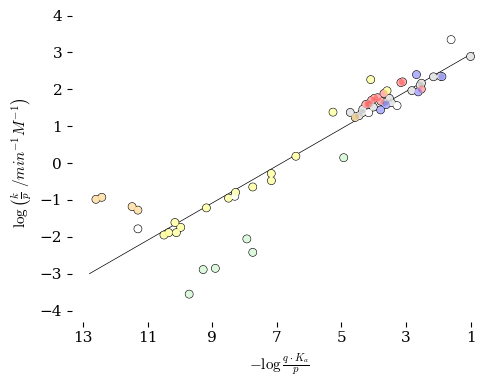

In [61]:
### CALCULATE MARKER SIZES doe OUTLINE = 0.5 pts

import numpy as np
def marker_area(diameter_points):
    return np.pi * diameter_points**2 / 4

size = 7 # points
circlesize = marker_area(size)
linewidth = 0.5
innersize = size - linewidth*2
innercirclesize = marker_area(innersize)

### READ DATA

data_file = "data/Data2All_labeled.csv"   

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

df["k"] = df["k"]/df["p"]
df["Ka"] = df["Ka"]*df["q"]/df["p"]

selected_df = df[
        df["label"].isin(["carb. acid", "mp-benz. acid", "o-benz. acid", "phenol"])
]

x = -np.log10(df["Ka"])
y = np.log10(df["k"])

def bronsted(pKa, alpha, logk0):
    """
    Bronsted equation: log(k) = -alpha * pKa + logk0
    """
    return -alpha * pKa + logk0

mod = lmfit.Model(bronsted) 

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(alpha = dict(value = 0.5), 
                       logk0 =  dict(value = 1),
                      )

# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pKa=x)   
print(result.fit_report())

x_fit = np.linspace(np.min(x)-0.1, np.max(x)+0.2, 50)     # make an array of 50 points that span the data range
y_fit = y1 = result.eval(pKa = x_fit)


######################
### Plots - NEW STYLED PLOTTING SECTION
######################

plt.rcdefaults()

style = "tufte.mplstyle"
#style = "S2_classic2.mplstyle"
style_name = style
plt.style.use(style_name)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,4])
ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))

# Settings for plot
ax.set(
#          title = Title,       
          ylabel=r"$\log{\left(\frac{k}{p}\ /min^{-1}M^{-1}\right)}$",                
          xlabel=r"$-\log{\frac{q\cdot K_a}{p}}$ ", 
          xlim=[13, 0.8],                  
          ylim=[-4,4],
#          yticks = [1,3,5,7],
          xticks = [13,11,9,7,5,3,1],
       )

### Data graphics
ax.scatter(x, y, marker = "o", s = circlesize, 
              color = "black", edgecolors = "none", 
              linewidths=0, zorder = 4) 
ax.scatter(x, y, marker = "o", s = innercirclesize, 
              color = "white", edgecolors = "none", 
              linewidths=0, zorder = 5) 
#ax.scatter(x, y, marker = "o", s = innercirclesize, 
#              color = "black", alpha = 0.1, edgecolors = "none", 
#              linewidths=0, zorder = 8) 

if 1:
    ax.plot(x_fit,y_fit, 
           marker = None, color = "black", 
           linewidth=0.5, 
           zorder = 3)

if 0:
    ax.fill_between(
        x_fit, ci_lower, ci_upper,
        linewidth = 0,
        facecolor="gray", 
        edgecolor = "gray", 
        alpha=0.20,
        label="95% Confidence Band",
        zorder = 0,
        )

################################################

if 1:
    selected_df = df[
        df["label"].isin(["carb. acid"])
        ]

    x = -np.log10(selected_df["Ka"])
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = innercirclesize, 
                  color = "black", alpha=0.1, edgecolors = "none", 
                  linewidths=0, zorder = 7) 

if 1:
    selected_df = df[
        df["label"].isin(["mp-benz. acid"])
        ]

    x = -np.log10(selected_df["Ka"])
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = innercirclesize, 
                  color = "red", alpha=0.3, edgecolors = "none", 
                  linewidths=0, zorder = 7) 

if 1:
    selected_df = df[
        df["label"].isin(["o-benz. acid"])
    ]

    x = -np.log10(selected_df["Ka"])
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = innercirclesize, 
                  color = "blue", alpha=0.3, edgecolors = "none", 
                  linewidths=0, zorder = 7) 

if 1:
    selected_df = df[
        df["label"].isin(["phenol"])
    ]

    x = -np.log10(selected_df["Ka"])
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = innercirclesize, 
                  color = "yellow", alpha=0.3, edgecolors = "none", 
                  linewidths=0, zorder = 7) 

if 1:
    selected_df = df[
        df["label"].isin(["other"])
    ]

    x = -np.log10(selected_df["Ka"])
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = innercirclesize, 
                  color = "white", alpha=0.3, edgecolors = "none", 
                  linewidths=0, zorder = 7) 



if 1:
    selected_df = df[
        df["label"].isin(["oxime"])
    ]

    x = -np.log10(selected_df["Ka"])
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = innercirclesize, 
                  color = "orange", alpha=0.3, edgecolors = "none", 
                  linewidths=0, zorder = 7) 


if 1:
    selected_df = df[
        df["label"].isin(["alkane", "enol"])
    ]

    x = -np.log10(selected_df["Ka"])
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "o", s = innercirclesize, 
                  color = "lightgreen", alpha=0.3, edgecolors = "none", 
                  linewidths=0, zorder = 7) 


################################################
### Output Plot
################################################

name = "plot6"

# Plot as .pdf
plt.savefig(f"plots/{name}.pdf")

### Set face of plot to transparent
ax.patch.set_facecolor([0, 0, 0, 0])  

# Plot as .png with transparent background
plt.savefig(f"plots/{name}.png", dpi=600, 
            facecolor = [0, 0, 0, 0],
        )
# display plot in notebook
plt.show()


## Stats or No Stats

How much of a difference is there in the plot when I dont use the statistical correction

WITH STATISTICAL CORRECTION
[[Model]]
    Model(bronsted)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 47
    # variables        = 2
    chi-square         = 2.23250241
    reduced chi-square = 0.04961116
    Akaike info crit   = -139.210151
    Bayesian info crit = -135.509856
    R-squared          = 0.97451527
[[Variables]]
    alpha:  0.52988739 +/- 0.01277389 (2.41%) (init = 0.5)
    logk0:  3.64437976 +/- 0.06983314 (1.92%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(alpha, logk0) = +0.8852

NO STATISTICAL CORRECTION
[[Model]]
    Model(bronsted)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 47
    # variables        = 2
    chi-square         = 2.20112594
    reduced chi-square = 0.04891391
    Akaike info crit   = -139.875393
    Bayesian info crit = -136.175098
    R-squared          = 0.97391076
[[Variables]]
    alpha:  0.55023777 +

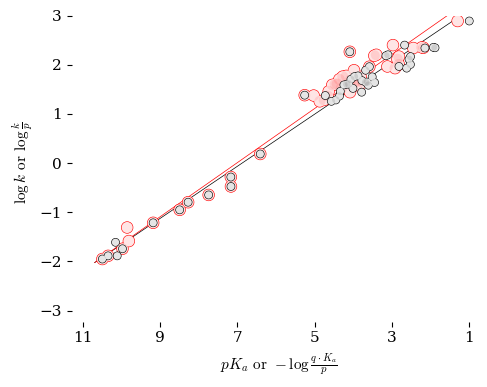

   NUMBER                  ACID     k        Ka  p  q       label
0       1             propionic  18.0  0.000027  1  2  carb. acid
1       2                acetic  19.2  0.000035  1  2  carb. acid
2       3  beta-phenylpropionic  23.0  0.000044  1  2  carb. acid
3       4       trimethylacetic  23.6  0.000019  1  2  carb. acid
4       5              crotonic  28.7  0.000046  1  2  carb. acid    NUMBER                  ACID     k        Ka  p  q       label
0       1             propionic  18.0  0.000013  1  2  carb. acid
1       2                acetic  19.2  0.000018  1  2  carb. acid
2       3  beta-phenylpropionic  23.0  0.000022  1  2  carb. acid
3       4       trimethylacetic  23.6  0.000009  1  2  carb. acid
4       5              crotonic  28.7  0.000023  1  2  carb. acid


In [58]:
### CALCULATE MARKER SIZES doe OUTLINE = 0.5 pts

import numpy as np
def marker_area(diameter_points):
    return np.pi * diameter_points**2 / 4

size = 7 # points
circlesize = marker_area(size)
linewidth = 0.5
innersize = size - linewidth*2
innercirclesize = marker_area(innersize)

### READ DATA

data_file = "data/Data2All_labeled.csv"   

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

df2 = df.copy()

df["k"] = df["k"]/df["p"]
df["Ka"] = df["Ka"]*df["q"]/df["p"]

selected_df = df[
        df["label"].isin(["carb. acid", "mp-benz. acid", "o-benz. acid", "phenol"])
]

x = -np.log10(selected_df["Ka"])
y = np.log10(selected_df["k"])

selected_df2 = df2[
        df2["label"].isin(["carb. acid", "mp-benz. acid", "o-benz. acid", "phenol"])
]

x2 = -np.log10(selected_df2["Ka"])
y2 = np.log10(selected_df2["k"])

def bronsted(pKa, alpha, logk0):
    """
    Bronsted equation: log(k) = -alpha * pKa + logk0
    """
    return -alpha * pKa + logk0

mod = lmfit.Model(bronsted) 

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(alpha = dict(value = 0.5), 
                       logk0 =  dict(value = 1),
                      )

# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pKa=x)   
print("WITH STATISTICAL CORRECTION")
print(result.fit_report())

x_fit = np.linspace(np.min(x)-0.1, np.max(x)+0.2, 50)     # make an array of 50 points that span the data range
y_fit = result.eval(pKa = x_fit)

result2 = mod.fit(y2, pars, pKa=x2)   
print()
print("NO STATISTICAL CORRECTION")
print(result2.fit_report())

x_fit2 = np.linspace(np.min(x2)-0.1, np.max(x2)+0.2, 50)     # make an array of 50 points that span the data range
y_fit2 = result2.eval(pKa = x_fit2)


######################
### Plots - NEW STYLED PLOTTING SECTION
######################

plt.rcdefaults()

style = "tufte.mplstyle"
#style = "S2_classic2.mplstyle"
style_name = style
plt.style.use(style_name)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,4])
ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))

# Settings for plot
ax.set(
#          title = Title,       
          ylabel=r"$\log{k}\text{ or } \log{\frac{k}{p}}$",                
          xlabel=r"$pK_a \text{ or }-\log{\frac{q\cdot K_a}{p}}$ ", 
          xlim=[11, 0.8],                  
          ylim=[-3,3],
#          yticks = [1,3,5,7],
          xticks = [11,9,7,5,3,1],
       )

### Data graphics
ax.scatter(x, y, marker = "o", s = circlesize, 
              color = "black", edgecolors = "none", 
              linewidths=0, zorder = 5) 
ax.scatter(x, y, marker = "o", s = innercirclesize, 
              color = "white", edgecolors = "none", 
              linewidths=0, zorder = 5) 
ax.scatter(x, y, marker = "o", s = innercirclesize, 
              color = "black", alpha = 0.1, edgecolors = "none", 
              linewidths=0, zorder = 5) 

size = 10 # points
circlesize = marker_area(size)
linewidth = 0.5
innersize = size - linewidth*2
innercirclesize = marker_area(innersize)


ax.scatter(x2, y2, marker = "o", s = circlesize, 
              color = "red", edgecolors = "none", 
              linewidths=0, zorder = 3) 
ax.scatter(x2, y2, marker = "o", s = innercirclesize, 
              color = "white", edgecolors = "none", 
              linewidths=0, zorder = 3) 
ax.scatter(x2, y2, marker = "o", s = innercirclesize, 
              color = "red", alpha = 0.1, edgecolors = "none", 
              linewidths=0, zorder = 3) 


if 1:
    ax.plot(x_fit,y_fit, 
           marker = None, color = "black", 
           linewidth=0.5, 
           zorder = 2)
    ax.plot(x_fit2,y_fit2, 
           marker = None, color = "red", 
           linewidth=0.5, 
           zorder = 2)

if 0:
    ax.fill_between(
        x_fit, ci_lower, ci_upper,
        linewidth = 0,
        facecolor="gray", 
        edgecolor = "gray", 
        alpha=0.20,
        label="95% Confidence Band",
        zorder = 0,
        )

################################################


################################################
### Output Plot
################################################

name = "plot7"

# Plot as .pdf
plt.savefig(f"plots/{name}.pdf")

### Set face of plot to transparent
ax.patch.set_facecolor([0, 0, 0, 0])  

# Plot as .png with transparent background
plt.savefig(f"plots/{name}.png", dpi=600, 
            facecolor = [0, 0, 0, 0],
        )
# display plot in notebook
plt.show()

print(df.head(), df2.head())